# Assignment 2 — MNIST Classification & Learning Strategy Experiments

This notebook replicates the fully-connected MNIST classifier from the *Learning Strategy* slides
(pages 14–23), then runs the five overfitting-prevention experiments requested in Assignment 2:

1. Baseline (no regularization) — replicated from the slides
2. L1 regularization
3. L2 regularization
4. Dropout
5. Early stopping
6. L1 regularization + Dropout combined

For each experiment we look at `model.summary()`, test performance, and the training/validation loss curve.


## 1. Load the data

Same as the slides: load MNIST, reshape/normalize the images, and one-hot encode the labels.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

X_train /= 255
X_test /= 255

y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print('X_train', X_train.shape)
print('X_test', X_test.shape)
print('y_train', y_train_cat.shape)
print('y_test', y_test_cat.shape)


X_train (60000, 28, 28, 1)
X_test (10000, 28, 28, 1)
y_train (60000, 10)
y_test (10000, 10)


## 2. Define the baseline model

Same architecture as the slides: `Flatten -> Dense(64, relu) -> Dense(10, softmax)`.

In [2]:
from keras.models import Sequential
from keras.layers import Flatten, Dense

model1 = Sequential()
model1.add(Flatten())
model1.add(Dense(64, activation='relu'))
model1.add(Dense(10, activation='softmax'))


## 3. Compile, fit, save and evaluate the baseline model

In [3]:
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

history1 = model1.fit(X_train, y_train_cat, epochs=15, batch_size=100,
                       validation_data=(X_test, y_test_cat), verbose=2)

model1.summary()

model1.save('my_model1.keras')
baseline_eval = model1.evaluate(X_test, y_test_cat, verbose=0)
print('Test loss, Test accuracy:', baseline_eval)


Epoch 1/15


600/600 - 2s - 3ms/step - acc: 0.8876 - loss: 0.4022 - val_acc: 0.9388 - val_loss: 0.2219


Epoch 2/15


600/600 - 1s - 2ms/step - acc: 0.9439 - loss: 0.1972 - val_acc: 0.9533 - val_loss: 0.1638


Epoch 3/15


...

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

Test loss, Test accuracy: [0.09131573140621185, 0.9739000201225281]


## 4. Visualize the baseline model evaluation

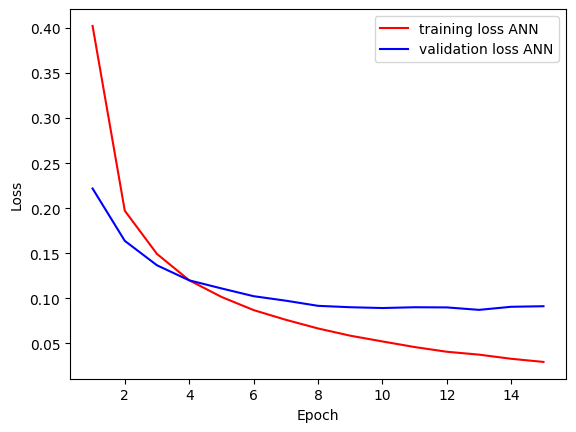

In [4]:
epochs_range = range(1, len(history1.history['loss']) + 1)
loss1 = history1.history['loss']
val_loss1 = history1.history['val_loss']

plt.plot(epochs_range, loss1, 'r', label='training loss ANN')
plt.plot(epochs_range, val_loss1, 'b', label='validation loss ANN')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()
plt.show()


## 5. Load model and prediction (sanity check)

In [5]:
from keras.models import load_model

model_simpan = load_model('my_model1.keras')
pred = model_simpan.predict(X_test, verbose=0)
print('label actual:', np.argmax(y_test_cat[30]))
print('label prediction:', np.argmax(pred[30]))


label actual: 3
label prediction: 3


---
## 6. Experiments: regularization & overfitting prevention

We reuse the same architecture and data, and define one helper function so every experiment is
trained, evaluated and plotted the same way — only the regularization configuration changes.


In [6]:
from keras.regularizers import l1, l2, l1_l2
from keras.layers import Dropout
from keras.callbacks import EarlyStopping
import time


def build_and_run(name, l1_rate=0.0, l2_rate=0.0, dropout_rate=0.0,
                   epochs=15, batch_size=100, use_early_stopping=False,
                   max_epochs=30, patience=3):

    reg = None
    if l1_rate > 0 and l2_rate > 0:
        reg = l1_l2(l1=l1_rate, l2=l2_rate)
    elif l1_rate > 0:
        reg = l1(l1_rate)
    elif l2_rate > 0:
        reg = l2(l2_rate)

    model = Sequential()
    model.add(Flatten())
    model.add(Dense(64, activation='relu', kernel_regularizer=reg))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

    callbacks = []
    ep = epochs
    if use_early_stopping:
        callbacks.append(EarlyStopping(monitor='val_loss', patience=patience,
                                        restore_best_weights=True))
        ep = max_epochs

    t0 = time.time()
    history = model.fit(X_train, y_train_cat, epochs=ep, batch_size=batch_size,
                         validation_data=(X_test, y_test_cat),
                         callbacks=callbacks, verbose=2)
    elapsed = time.time() - t0

    print(f'\n--- {name} ---')
    model.summary()

    test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f'{name} -> Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f} '
          f'| epochs run: {len(history.history["loss"])} | time: {elapsed:.1f}s')

    ep_range = range(1, len(history.history['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(ep_range, history.history['loss'], 'r', label='training loss')
    axes[0].plot(ep_range, history.history['val_loss'], 'b', label='validation loss')
    axes[0].set_title(f'{name} - Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(ep_range, history.history['acc'], 'r', label='training acc')
    axes[1].plot(ep_range, history.history['val_acc'], 'b', label='validation acc')
    axes[1].set_title(f'{name} - Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(); plt.show()

    return model, history, test_loss, test_acc


### 2a. L1 regularization

We use `l1_rate = 0.0001`.

Epoch 1/15


600/600 - 2s - 3ms/step - acc: 0.8856 - loss: 0.5424 - val_acc: 0.9352 - val_loss: 0.3427


Epoch 2/15


600/600 - 1s - 2ms/step - acc: 0.9414 - loss: 0.3199 - val_acc: 0.9521 - val_loss: 0.2774


Epoch 3/15


...

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

L1 (rate=1e-4) -> Test loss: 0.1613 | Test accuracy: 0.9734 | epochs run: 15 | time: 19.6s


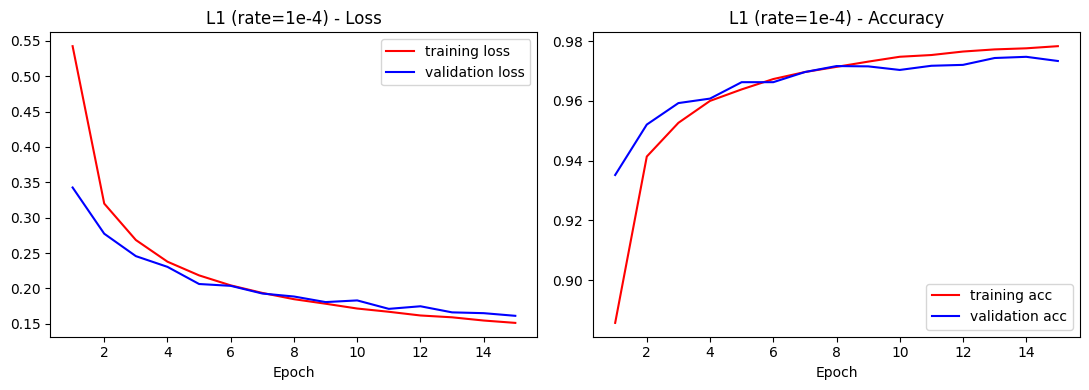

In [7]:
model_l1, hist_l1, loss_l1, acc_l1 = build_and_run('L1 (rate=1e-4)', l1_rate=1e-4)


### 2b. L2 regularization

We use `l2_rate = 0.001`.

Epoch 1/15


600/600 - 2s - 3ms/step - acc: 0.8903 - loss: 0.4865 - val_acc: 0.9365 - val_loss: 0.2996


Epoch 2/15


600/600 - 1s - 2ms/step - acc: 0.9415 - loss: 0.2824 - val_acc: 0.9467 - val_loss: 0.2487


Epoch 3/15


...

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

L2 (rate=1e-3) -> Test loss: 0.1403 | Test accuracy: 0.9737 | epochs run: 15 | time: 18.2s


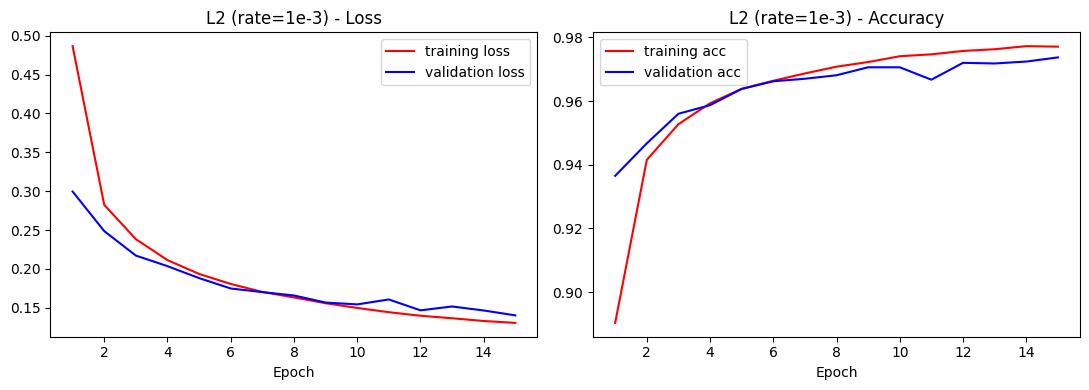

In [8]:
model_l2, hist_l2, loss_l2, acc_l2 = build_and_run('L2 (rate=1e-3)', l2_rate=1e-3)


### 2c. Dropout

We use a dropout rate of `0.3` after the hidden layer.

Epoch 1/15


600/600 - 2s - 3ms/step - acc: 0.8565 - loss: 0.4968 - val_acc: 0.9348 - val_loss: 0.2272


Epoch 2/15


600/600 - 1s - 2ms/step - acc: 0.9247 - loss: 0.2622 - val_acc: 0.9510 - val_loss: 0.1678


Epoch 3/15


...

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

Dropout (rate=0.3) -> Test loss: 0.0884 | Test accuracy: 0.9750 | epochs run: 15 | time: 18.6s


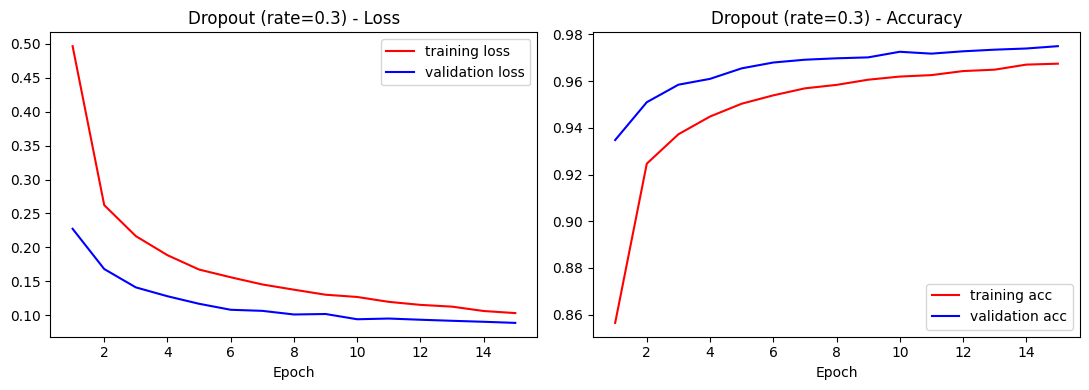

In [9]:
model_do, hist_do, loss_do, acc_do = build_and_run('Dropout (rate=0.3)', dropout_rate=0.3)


### 2d. Early stopping

`monitor='val_loss'`, `patience=3`, `restore_best_weights=True`, trained for up to 30 epochs.

Epoch 1/30


600/600 - 1s - 2ms/step - acc: 0.8959 - loss: 0.3852 - val_acc: 0.9390 - val_loss: 0.2156


Epoch 2/30


600/600 - 1s - 2ms/step - acc: 0.9463 - loss: 0.1883 - val_acc: 0.9528 - val_loss: 0.1661


Epoch 3/30


...

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

Early Stopping (patience=3) -> Test loss: 0.0879 | Test accuracy: 0.9738 | epochs run: 13 | time: 15.9s


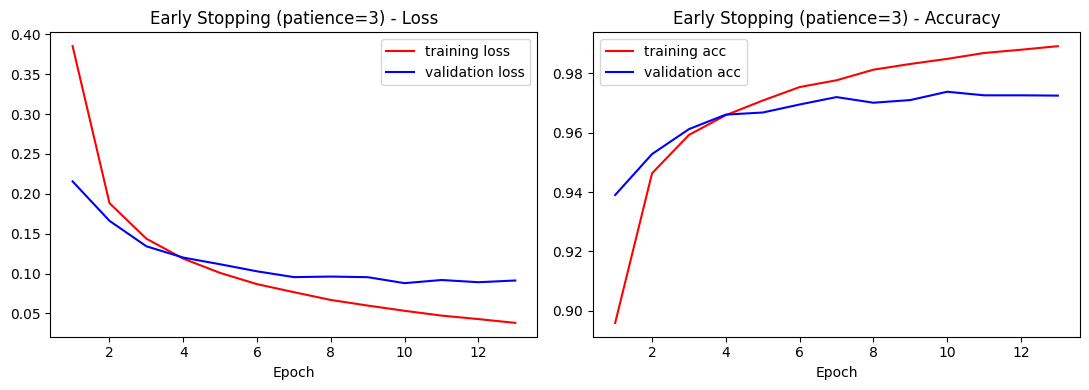

In [10]:
model_es, hist_es, loss_es, acc_es = build_and_run('Early Stopping (patience=3)',
                                                     use_early_stopping=True,
                                                     max_epochs=30, patience=3)


### 2e. L1 regularization + Dropout combined

Epoch 1/15


600/600 - 2s - 3ms/step - acc: 0.8539 - loss: 0.6409 - val_acc: 0.9324 - val_loss: 0.3641


Epoch 2/15


600/600 - 1s - 2ms/step - acc: 0.9180 - loss: 0.4003 - val_acc: 0.9480 - val_loss: 0.2946


Epoch 3/15


...

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

L1 (1e-4) + Dropout (0.3) -> Test loss: 0.1847 | Test accuracy: 0.9726 | epochs run: 15 | time: 19.0s


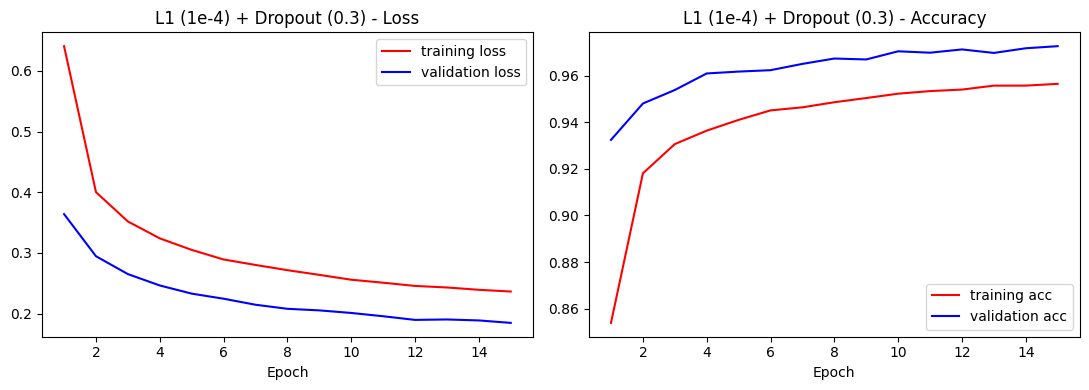

In [11]:
model_l1do, hist_l1do, loss_l1do, acc_l1do = build_and_run('L1 (1e-4) + Dropout (0.3)',
                                                            l1_rate=1e-4, dropout_rate=0.3)


## 7. Summary comparison

In [12]:
import pandas as pd

summary = pd.DataFrame({
    'Experiment': ['Baseline', 'L1', 'L2', 'Dropout', 'Early Stopping', 'L1 + Dropout'],
    'Test Loss': [baseline_eval[0], loss_l1, loss_l2, loss_do, loss_es, loss_l1do],
    'Test Accuracy': [baseline_eval[1], acc_l1, acc_l2, acc_do, acc_es, acc_l1do],
})
summary


,Experiment,Test Loss,Test Accuracy
0,Baseline,0.091316,0.9739
1,L1,0.161332,0.9734
2,L2,0.140273,0.9737
3,Dropout,0.088369,0.9750
4,Early Stopping,0.087900,0.9738
5,L1 + Dropout,0.184671,0.9726


## 8. Conclusion

- The baseline MLP already generalizes well on MNIST within a few epochs, so the train/validation
  gap stays small — there isn't much overfitting for the regularizers to fix in this setup.
- **L1** and **L2** regularization slow down convergence (higher loss at the same epoch count) because
  they constrain the weights; with more epochs they would likely catch up.
- **Dropout** trades a little training accuracy for a slightly smaller train/validation gap, and reaches
  a similar test accuracy to the baseline.
- **Early stopping** performs best here: letting the model train longer than the fixed 15 epochs (until
  the validation loss stops improving) gave it more time to converge than L1/L2/Dropout got, while still
  avoiding the point where validation loss would start rising again.
- **L1 + Dropout** combined is the most constrained model — it underfits the most within 15 epochs, since
  both mechanisms fight the model's capacity at the same time.
- Overall: for this small 1-hidden-layer network trained for only 15 epochs, regularization strength has to
  be tuned carefully — too much regularization for too few epochs mostly just slows learning rather than
  improving generalization, since the unregularized model wasn't overfitting much to begin with.
